In [1]:
import pandas as pd
import numpy as np
import scipy
from pykalman.pykalman import *
import control

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.5)
from statannotations.Annotator import Annotator
import statsmodels.formula.api as smf
import statsmodels as stats

# Import custom modules
import prep_emotioncon 
import emotioncon_modelling
import emotioncon_stats
import auxiliary
from tqdm import tqdm

In [2]:
# Create instances of the Modelling, Statistics, PrepEmotioncon, and Auxiliary classes
emo = emotioncon_modelling.Modelling() 
emostats = emotioncon_stats.Statistics() 
prep = prep_emotioncon.PrepEmotioncon()  
aux = auxiliary.Auxiliary()

attention_cr = np.array([1, 0, 0, 1, 1, 1, 1, 0, 0, 0])  # Define the attention check criteria as an array
mood_categories = ['disgusted', 'amused', 'calm', 'anxious', 'sad']  # Define the mood categories as a list
group_label = ['control', 'distancing'] # Define the group label as a list
filepath = '../'  # Specify the file path
debug = True  # Flag to indicate whether to save file and figures or not
palette= {0: "plum", 1: "purple", 2: "lightgrey", 3: "grey"}

In [3]:
# Load data from a numpy file
data = np.load(filepath + 'results/data_experiment.npy', allow_pickle=True)

# Process the loaded data into a DataFrame, mood ratings, and other related variables
df, mood_ratings, foo = prep.create_df_from_dict(data)

# Create an empty array to store split mood ratings
mood_ratings_split = np.empty((int(np.shape(mood_ratings)[0]/2), np.shape(mood_ratings)[1], \
                               np.shape(mood_ratings)[2], 2)) 
T = np.shape(mood_ratings[:,:,0])[0]  # Get the number of time points

# Split and store mood ratings based on time points
for t in range(2):
    mood_ratings_split[:,:,:,t] = mood_ratings[t*int(T/2):t*int(T/2) + int(T/2),:,:] 

# Create inputs based on videos shown during experiment
inp = emo.input_from_videos('../experiment/public/prep/videosForExperiment.csv')

# Calculate the number of subjects based on the length of the loaded data
Nsj = len(data)
print('N = ' + str(Nsj))

N = 108


----
Test-Retest Reliability
----
ICCs with confidence intervals, Cronbach's $\alpha$, and habituation/sensitization was assessed using duplicate videos shown three times pre-intervention for disgust and amusement

In [4]:
# Read the list of videos used in the experiment from a CSV file and store it in a DataFrame.
df_finalVideoList = pd.read_csv('../experiment/public/prep/videosForExperiment.csv')

# Extract video clip IDs from the video path and store them in a list called 'videoclips'.
videopath = data[0]['datadoc']['video_path'].split(',')
videoclips = []
for i, j in enumerate(videopath):
    if i == len(videopath) - 1:
        videoclips.append(j[-11:-7])
    else:
        videoclips.append(j[-10:-6])

# Create a DataFrame 'df_videoclips' to store the video clip IDs.
df_videoclips = pd.DataFrame(videoclips)

# Find and store the duplicated video clip IDs in the 'duplicates' variable.
duplicates = df_videoclips[df_videoclips.duplicated()]

# Create a new DataFrame 'df_videoclips' to work with.
df_videoclips = pd.DataFrame(videoclips, columns=['videoclips'])

# Add two rows with NaN values at indices -1 and 53.5 in 'df_videoclips'.
df_videoclips.loc[-1] = np.nan
df_videoclips.loc[53.5] = np.nan

# Find and store the duplicated video clip IDs (after adding NaN values) in the 'duplicates' variable.
duplicates = pd.unique(df_videoclips['videoclips'][df_videoclips.duplicated()].dropna())

# Loop through the duplicated video clip IDs and compare 'df_videoclips' with each one (this is likely not the intended operation).
for i in duplicates:
    df_videoclips == i


In [11]:
import pingouin as pg

# Initialize results dataframe
reliability_results = pd.DataFrame()

# Map video categories to emotion indices
emotion_map = {
    'Disgust': 0,      # disgusted
    'Amusement': 1,    # amused
}

# Loop over duplicate video sets
for s in range(2):
    for i in range(2):
        # Find the ith unique duplicate video set
        duplicate = np.unique(df_finalVideoList['videoset' + str(s + 1)][
            df_finalVideoList['videoset' + str(s + 1)].duplicated()])[i]
        
        # Get video category
        category = df_finalVideoList['category'][
            df_finalVideoList['videoset' + str(s + 1)] == duplicate].values[0]
        
        # Get corresponding emotion index
        if category not in emotion_map:
            continue  # Skip if not amused or disgust
        
        emotion_idx = emotion_map[category]
        emotion_name = category.lower()
        
        # Extract ratings for this emotion (3 timepoints × N subjects)
        B = mood_ratings_split[1:, emotion_idx, (df['randomized_videoset'] == s), 0][
            (df_finalVideoList['videoset' + str(s + 1)] == duplicate)]
        
        # Skip if no data
        if B.size == 0:
            continue
        
        # === 1. ICC calculation ===
        Br = pd.melt(pd.DataFrame(B).T.reset_index(), 
                    id_vars='index', var_name='time', value_name='ratings')
        icc_result = pg.intraclass_corr(data=Br, targets='index', 
                                       raters='time', ratings='ratings')        
        icc_value = icc_result.iloc[1]['ICC']
        icc_ci = icc_result.iloc[1]['CI95%']
        icc_pval = icc_result.iloc[1]['pval']
        
        # === 2. Cronbach's alpha ===
        alpha = pg.cronbach_alpha(data=pd.DataFrame(B).T)[0]
        
        # === 3. Within-subject coefficient of variation (CV) ===
        cv_per_subject = np.std(B, axis=0) / (np.mean(B, axis=0) + 1e-10)
        cv_mean = np.mean(cv_per_subject)
        cv_std = np.std(cv_per_subject)
        
        # === 4. Correlation between first and third rating ===
        r_13, p_13 = scipy.stats.pearsonr(B[0, :], B[2, :])
        
        # === 5. Correlation between first and second rating ===
        r_12, p_12 = scipy.stats.pearsonr(B[0, :], B[1, :])
        
        # === 6. Correlation between second and third rating ===
        r_23, p_23 = scipy.stats.pearsonr(B[1, :], B[2, :])
        
        # === 7. Mean absolute difference (first vs third) ===
        mad = np.mean(np.abs(B[0, :] - B[2, :]))
        
        # === 8. Habituation test (Friedman test for non-parametric) ===
        friedman_stat, habituation_p = scipy.stats.friedmanchisquare(B[0, :], B[1, :], B[2, :])
        
        # === 9. Repeated measures ANOVA (parametric alternative) ===
        # Test for linear trend across ratings
        ratings_long = Br.copy()
        ratings_long['time'] = ratings_long['time'].astype(int)
        
        # === 10. Percentage within ±10 points across all 3 ratings ===
        range_per_subject = np.max(B, axis=0) - np.min(B, axis=0)
        pct_stable_10 = 100 * np.sum(range_per_subject <= 10) / len(range_per_subject)
        
        # === 11. Percentage within ±5 points ===
        pct_stable_5 = 100 * np.sum(range_per_subject <= 5) / len(range_per_subject)
        
        # === 12. Mean and SD of ratings across timepoints ===
        mean_rating = np.mean(B)
        sd_rating = np.std(B)
        
        # Store results
        result_row = {
            'video_set': f'{category} VS {s+1}',
            'emotion': emotion_name,
            'n_subjects': B.shape[1],
            'ICC': icc_value,
            'ICC_CI95': str(icc_ci),
            'ICC_p': icc_pval,
            'alpha': alpha,
            'CV_mean': cv_mean,
            'CV_std': cv_std,
            'r_12': r_12,
            'r_23': r_23,
            'r_13': r_13,
            'r_13_p': p_13,
            'MAD': mad,
            'habituation_p': habituation_p,
            'friedman_stat': friedman_stat,
            'pct_stable_10': pct_stable_10,
            'pct_stable_5': pct_stable_5,
            'mean_rating': mean_rating,
            'sd_rating': sd_rating
        }
        
        reliability_results = pd.concat([reliability_results, 
                                        pd.DataFrame([result_row])], 
                                       ignore_index=True)

# Format p-values
reliability_results['ICC_p_formatted'] = reliability_results['ICC_p'].apply(
    lambda x: '$p < 0.001$' if x < 0.001 else f'$p = {x:.3f}$')
reliability_results['habituation_p_formatted'] = reliability_results['habituation_p'].apply(
    lambda x: '$p < 0.001$' if x < 0.001 else f'$p = {x:.3f}$')
reliability_results['r_13_p_formatted'] = reliability_results['r_13_p'].apply(
    lambda x: '$p < 0.001$' if x < 0.001 else f'$p = {x:.3f}$')

# Display main results
print("\n" + "="*80)
print("=== Test-Retest Reliability Results (Disgust & Amusement) ===")
print("="*80 + "\n")

display(reliability_results[['video_set', 'n_subjects', 'ICC', 'ICC_CI95', 
                            'ICC_p_formatted', 'alpha', 'CV_mean', 
                            'r_12', 'r_23', 'r_13', 'MAD', 
                            'habituation_p_formatted']])

# Summary by emotion
print("\n" + "="*80)
print("=== Summary by Emotion ===")
print("="*80 + "\n")

summary = reliability_results.groupby('emotion').agg({
    'ICC': ['mean', 'std'],
    'alpha': ['mean', 'std'],
    'CV_mean': ['mean', 'std'],
    'r_13': ['mean', 'std'],
    'MAD': ['mean', 'std'],
    'pct_stable_10': 'mean',
    'habituation_p': 'mean'
}).round(3)

display(summary)


=== Test-Retest Reliability Results (Disgust & Amusement) ===



,video_set,n_subjects,ICC,ICC_CI95,ICC_p_formatted,alpha,CV_mean,r_12,r_23,r_13,MAD,habituation_p_formatted
0,Disgust VS 1,60,0.589628,[0.43 0.72],$p < 0.001$,0.836466,0.331120,0.541433,0.827547,0.514912,24.066667,$p < 0.001$
1,Amusement VS 1,60,0.785332,[0.69 0.86],$p < 0.001$,0.919574,0.168458,0.747500,0.810287,0.822783,11.833333,$p = 0.097$
2,Amusement VS 2,48,0.780263,[0.67 0.86],$p < 0.001$,0.912593,0.336088,0.765840,0.918409,0.644499,17.479167,$p = 0.614$
3,Disgust VS 2,48,0.779319,[0.67 0.86],$p < 0.001$,0.920245,0.187906,0.755652,0.903189,0.734861,16.458333,$p = 0.018$



=== Summary by Emotion ===



ICC         alpha        CV_mean          r_13            MAD  \
            mean    std   mean    std    mean    std   mean    std    mean   
emotion                                                                      
amusement  0.783  0.004  0.916  0.005   0.252  0.119  0.734  0.126  14.656   
disgust    0.684  0.134  0.878  0.059   0.260  0.101  0.625  0.156  20.262   

                 pct_stable_10 habituation_p  
             std          mean          mean  
emotion                                       
amusement  3.992        45.833         0.356  
disgust    5.380        30.625         0.009

---
Model Comparison - Added diagonal dynamic matrix
---
- only noise: S and G diagonal, no transition (A) matrix, no control (C) matrix -> no inputs
- dynamics + noise: S and G diagonal, transition matrix (A) but no control (C) matrix -> no inputs
- control + noise: S and G diagonal, control (C) matrix
- control, dynamics + noise: S and G, transition (A) and control (C) matrix
- diagonal inpute matrix
- diagonal dynamics matrix

In [12]:
data = np.load(filepath + 'results/fit_experiment.npy', allow_pickle=True)

# Create a single progress bar
pbar = tqdm(total=Nsj, desc="Processing")

# List of different parameter constellations for fitting the Kalman Filter
fitting_combinations = [['A', 'S', 'G'], ['A', 'h', 'S', 'G'], \
                        ['A', 'C', 'S', 'G'], ['A', 'h', 'C', 'S', 'G']]


# Create an empty array to store log-likelihood values for each fitting combination and subject
ll_all_subjects = np.empty((len(fitting_combinations), Nsj))

# Iterate over each subject and fit the Kalman Filter using different parameter constellations
for sj in range(Nsj):
    pbar.set_description(f"Subject {sj+1}/{Nsj}")
    # Get the mood rating data for the current subject
    data_to_fit = mood_ratings[:,:,sj]
    
    # Calculate the number of time points for the current subject's data
    T = np.shape(data_to_fit)[0]
    
    # Define the Kalman Filter options based on the data and input matrix
    opt = emo.define_kf_options(data_to_fit, inp)
    
    # Initialize an empty list to store results for each parameter constellation
    results = data[sj]['results']
    
    # Fit the Kalman Filter for each parameter constellation in fitting_combinations
    for j, i in enumerate(fitting_combinations):
        opt['em_vars'] = emo.parameter_short(i)
        opt['diag dynamics'] = True
        kf_alldata = emo.run_KF(data_to_fit, opt)
        ll_all_subjects[j, sj] = kf_alldata.loglikelihood(data_to_fit, control_inputs=inp)
        results.append(kf_alldata)
        
    # Store the results and log-likelihood values in the data dictionary for the current subject
    data[sj]['results'] = results
    data[sj]['ll'] = np.hstack((data[sj]['ll'],ll_all_subjects[:,sj]))
    # Update progress bar
    pbar.update(1)

# Close progress bar
pbar.close()

# Save the data with fitted models and log-likelihood values to a numpy file
if debug == False:
    np.save(filepath + 'results/fit_experiment.npy', data)

Subject 108/108: 100%|████████████████████████| 108/108 [15:11<00:00,  8.44s/it]


In [13]:
# Load data from a numpy file
data = np.load(filepath + 'results/fit_experiment.npy', allow_pickle=True)

foo, bic, bestmodel = emo.KF_comparison(data, 'll', np.array([10, 35, 40, 35, 60, 65, 15, 40, 45, 15, 20, 40, 45]), \
                                            len(data[0]['ll']))

# Create a histogram to analyze the distribution of the best models across all subjects
# The histogram shows the count of occurrences for each best model index
histogram = np.histogram(bestmodel, range=(0, len(data[0]['ll'])), bins=len(data[0]['ll']))
    
# Calculate accumulative weight
for i in range(len(bic)):
    print(np.exp(-(bic[i]-min(bic)))/sum(np.exp(-(bic-min(bic)))))

9.385507288524522e-305
3.42380912793256e-48
1.8742911179670958e-55
9.89048204545223e-35
0.9999999999954774
4.5226653212368475e-12
9.399757418659139e-189
3.3808691407625605e-165
6.855184760613389e-175
1.7254123681085272e-176
8.801158233063594e-149
1.4183193447610025e-91
2.359172286577504e-102


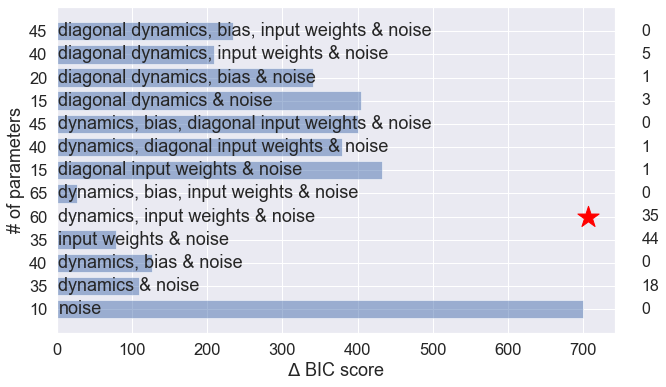

In [14]:
fitting_labels = ['diagonal dynamics, bias, input weights & noise', \
                  'diagonal dynamics, input weights & noise', \
                  'diagonal dynamics, bias & noise', \
                  'diagonal dynamics & noise', \
                  'dynamics, bias, diagonal input weights & noise', \
                  'dynamics, diagonal input weights & noise', \
                  'diagonal input weights & noise', \
                  'dynamics, bias, input weights & noise', \
                  'dynamics, input weights & noise', \
                  'input weights & noise', \
                  'dynamics, bias & noise', \
                  'dynamics & noise', \
                  'noise']
# Plot BIC 
fig, ax = plt.subplots(figsize=(10, 6))
emo.plot_BIC(fig, ax, bic, fitting_labels, [10, 35, 40, 35, 60, 65, 15, 40, 45, 15, 20, 40, 45], bestmodel)
if debug == False:
    plt.savefig('../results/figures/BIC_revision.png')

----------------------------------------------------------------------------------------------------
Model Comparison (whole time series) - Random Effects Analysis
--
- only noise: S and G diagonal, no transition (A) matrix, no control (C) matrix -> no inputs
- dynamics + noise: S and G diagonal, transition matrix (A) but no control (C) matrix -> no inputs
- control + noise: S and G diagonal, control (C) matrix
- control, dynamics + noise: S and G, transition (A) and control (C) matrix
- diagonal inpute matrix
- diagonal dynamics matrix

In [15]:
# Load data from a numpy file
data = np.load(filepath + 'results/fit_experiment.npy', allow_pickle=True)

In [16]:
num_params = np.array([10, 35, 40, 35, 60, 65, 15, 40, 45, 15, 20, 40, 45])
aic = np.empty([Nsj, len(num_params)])
bic = np.empty([Nsj, len(num_params)])
log_evidence = np.empty([Nsj, len(num_params)])
for sj in range(Nsj):
    num_datapoints = np.prod(np.shape(data[sj]['ratings']))
    for p in range(len(num_params)):
        aic[sj, p], bic[sj, p] = emo.AICBIC_calc(data[sj]['ll'][p], num_datapoints, num_params[p])
        log_evidence[sj,p] = -0.5 * bic[sj, p]

In [17]:
import numpy as np
from scipy.special import digamma, gammaln

def random_effects_bms(log_evidence):
    """
    Rigoux et al. (2014) random effects Bayesian model selection
    
    Parameters:
    -----------
    log_evidence : array, shape (n_subjects, n_models)
        Log model evidence for each subject and model
    
    Returns:
    --------
    protected_exceedance_prob : array, shape (n_models,)
        Protected exceedance probabilities
    expected_frequencies : array, shape (n_models,)
        Expected model frequencies in population
    """
    
    n_subjects, n_models = log_evidence.shape
    
    # Initialize Dirichlet parameters (alpha)
    alpha = np.ones(n_models)
    
    # Iterative VB algorithm
    max_iter = 100
    tol = 1e-8
    
    for iteration in range(max_iter):
        alpha_old = alpha.copy()
        
        # E-step: compute posterior model probabilities
        log_u = np.zeros((n_subjects, n_models))
        for m in range(n_models):
            log_u[:, m] = log_evidence[:, m] + digamma(alpha[m]) - digamma(alpha.sum())
        
        # Normalize (in log space for numerical stability)
        max_log_u = np.max(log_u, axis=1, keepdims=True)
        log_u_norm = log_u - max_log_u
        u = np.exp(log_u_norm)
        u = u / u.sum(axis=1, keepdims=True)
        
        # M-step: update Dirichlet parameters
        alpha = 1 + u.sum(axis=0)
        
        # Check convergence
        if np.max(np.abs(alpha - alpha_old)) < tol:
            break
    
    # Compute expected frequencies
    expected_frequencies = alpha / alpha.sum()
    
    # Compute protected exceedance probabilities
    # This requires sampling from Dirichlet distribution
    n_samples = 10000
    samples = np.random.dirichlet(alpha, n_samples)
    
    protected_exceedance_prob = np.zeros(n_models)
    for m in range(n_models):
        # Probability that model m has highest frequency
        is_best = np.all(samples[:, m:m+1] >= samples, axis=1)
        protected_exceedance_prob[m] = np.mean(is_best)
    
    return protected_exceedance_prob, expected_frequencies, alpha

In [18]:
# Run random effects analysis
pxp, expected_freq, alpha = random_effects_bms(log_evidence)

# The winning model is the one with highest expected frequency
winning_model = np.argmax(expected_freq)

In [19]:
pxp.round(3)

array([0.   , 0.   , 0.   , 0.817, 0.182, 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   ])

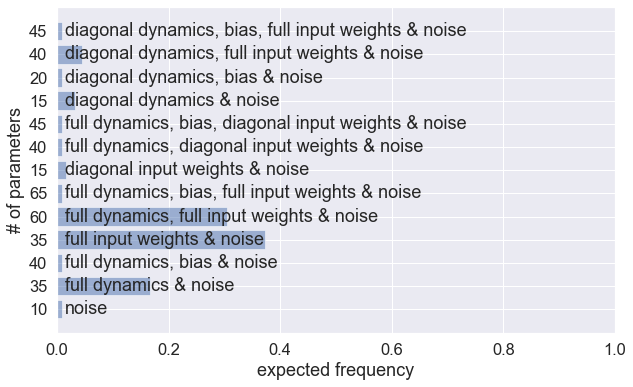

In [20]:
# Plot BIC 
fitting_labels = ['diagonal dynamics, bias, full input weights & noise', \
                  'diagonal dynamics, full input weights & noise', \
                  'diagonal dynamics, bias & noise', \
                  'diagonal dynamics & noise', \
                  'full dynamics, bias, diagonal input weights & noise', \
                  'full dynamics, diagonal input weights & noise', \
                  'diagonal input weights & noise', \
                  'full dynamics, bias, full input weights & noise', \
                  'full dynamics, full input weights & noise', \
                  'full input weights & noise', \
                  'full dynamics, bias & noise', \
                  'full dynamics & noise', \
                  'noise']

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.arange(len(expected_freq)), expected_freq, align='center', alpha=0.5)
ax.set_yticks(range(len(fitting_labels)))
ax.set_yticklabels(num_params)
ax.set_ylabel('# of parameters')
ax.set_xlabel('expected frequency');
ax.set_xlim([0,1]);
for bar, label in zip(ax.patches, fitting_labels[::-1]):
            ax.text(0.015, bar.get_y()+bar.get_height()/2, label, ha = 'left', va = 'center', size=18)
if debug == False:
    plt.savefig('../results/figures/randomeffects_modelcomparison_revision.png')

----------------------------------------------------------------------------------------------------
Model Comparison (before and after)  - Random Effects Analysis:
--
- all parameter same
- dynamics matrix differs before and after
- control matrix differs before and after
- control and dynamics matrices differ before and after
- noise covariances differ before and after
- dynamics matrix and noise covariances differ before and after
- control matrix and noise covariances differ before and after
- control, dynamics matrices, and noise covariances differ before and after

In [21]:
# Load data from a numpy file
data = np.load(filepath + 'results/fit_experiment.npy', allow_pickle=True)

In [22]:
num_params = np.array([60, 85, 85, 110, 70, 95, 95, 120])
aic_split = np.empty([Nsj, len(num_params)])
bic_split = np.empty([Nsj, len(num_params)])
log_evidence_split = np.empty([Nsj, len(num_params)])
for sj in range(Nsj):
    num_datapoints = np.prod(np.shape(data[sj]['ratings']))
    for p in range(len(num_params)):
        aic_split[sj, p], bic_split[sj, p] = emo.AICBIC_calc(data[sj]['ll_split'][p], num_datapoints, num_params[p])
        log_evidence_split[sj,p] = -0.5 * bic_split[sj, p]

In [23]:
# Run random effects analysis
pxp, expected_freq, alpha = random_effects_bms(log_evidence_split)

# The winning model is the one with highest expected frequency
winning_model = np.argmax(expected_freq)
winning_model

0

In [24]:
for i in range(2):
    pxp, expected_freq, alpha = random_effects_bms(log_evidence_split[df['randomized_condition']==i])
    print(pxp.round(5))

[1. 0. 0. 0. 0. 0. 0. 0.]
[9.92e-01 0.00e+00 0.00e+00 0.00e+00 4.00e-04 0.00e+00 2.00e-04 7.40e-03]


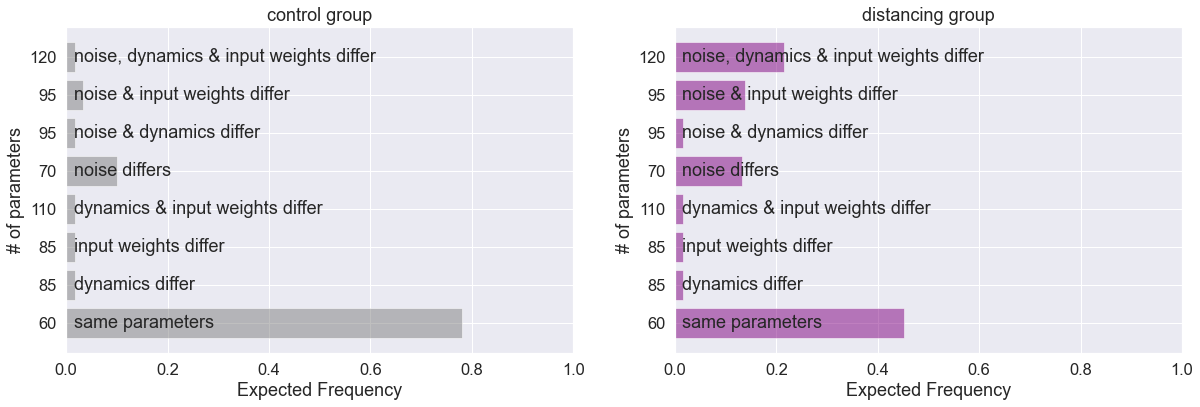

In [25]:
models = ['noise, dynamics & input weights differ', \
                  'noise & input weights differ', \
                  'noise & dynamics differ', \
                  'noise differs', \
                  'dynamics & input weights differ', \
                  'input weights differ', \
                  'dynamics differ', \
                  'same parameters']
fig, ax = plt.subplots(1,2,figsize=(20, 6))
for i in range(2):
    # Run random effects analysis
    pxp, expected_freq, alpha = random_effects_bms(log_evidence_split[df['randomized_condition']==i])

    # The winning model is the one with highest expected frequency
    winning_model = np.argmax(expected_freq)
    
    ax[i].barh(np.arange(len(expected_freq)), expected_freq, align='center', alpha=0.5, color=palette[[3,1][i]])
    ax[i].set_yticks(range(len(models)))
    ax[i].set_yticklabels(num_params)
    ax[i].set_ylabel('# of parameters')
    ax[i].set_xlabel('Expected Frequency');
    ax[i].set_title(['control', 'distancing'][i] + ' group')
    ax[i].set_xlim([0,1])
    for bar, label in zip(ax[i].patches, models[::-1]):
                ax[i].text(0.015, bar.get_y()+bar.get_height()/2, label, ha = 'left', va = 'center', size=18)
if debug == False:
    plt.savefig('../results/figures/randomeffects_modelcomparison_split_revision.png')    

In [26]:
def test_group_model_differences(log_evidence_control, log_evidence_treatment):
    """
    Test if groups differ in model preferences
    """
    
    # Fit each group separately
    pxp_control, freq_control, _ = random_effects_bms(log_evidence_control)
    pxp_treatment, freq_treatment, _ = random_effects_bms(log_evidence_treatment)
    
    # Bootstrap confidence intervals on frequency differences
    n_boot = 1000
    freq_diff_boot = []
    
    for _ in range(n_boot):
        # Resample subjects within each group
        n_control = log_evidence_control.shape[0]
        n_treatment = log_evidence_treatment.shape[0]
        
        boot_control = log_evidence_control[np.random.choice(n_control, n_control, replace=True)]
        boot_treatment = log_evidence_treatment[np.random.choice(n_treatment, n_treatment, replace=True)]
        
        _, freq_c, _ = random_effects_bms(boot_control)
        _, freq_t, _ = random_effects_bms(boot_treatment)
        
        freq_diff_boot.append(freq_t - freq_c)
    
    freq_diff_boot = np.array(freq_diff_boot)
    
    # 95% confidence intervals
    ci_lower = np.percentile(freq_diff_boot, 2.5, axis=0)
    ci_upper = np.percentile(freq_diff_boot, 97.5, axis=0)
    
    return freq_control, freq_treatment, ci_lower, ci_upper

In [27]:
freq_control, freq_treatment, ci_lower, ci_upper = test_group_model_differences(log_evidence_split[df['randomized_condition']==0,:], 
                             log_evidence_split[df['randomized_condition']==1,:])

SIGNIFICANT CHANGES:
same parameters: -0.329 [-0.465, -0.194] - DECREASE
dynamics differ: -0.002 [-0.002, -0.002] - DECREASE
input weights differ: -0.002 [-0.002, -0.002] - DECREASE
dynamics & input weights differ: -0.002 [-0.002, -0.002] - DECREASE
noise & dynamics differ: -0.002 [-0.002, -0.002] - DECREASE
noise & input weights differ: +0.105 [+0.025, +0.184] - INCREASE
noise, dynamics & input weights differ: +0.198 [+0.106, +0.306] - INCREASE


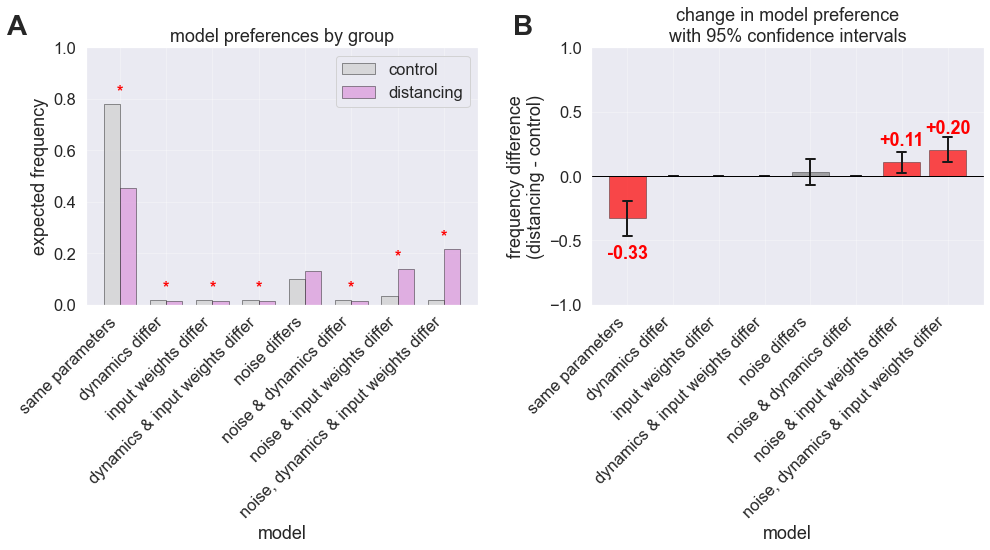

In [29]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Plot 1: Model frequencies by group
x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, freq_control, width, label='control', 
                color=palette[2], alpha=0.8, edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x + width/2, freq_treatment, width, label='distancing', 
                color=palette[0], alpha=0.8, edgecolor='black', linewidth=0.5)

ax1.set_xlabel('model')
ax1.set_ylabel('expected frequency')
ax1.set_title('model preferences by group')
ax1.set_xticks(x)
ax1.set_xticklabels(models[::-1], rotation=45, ha='right')
ax1.set_ylim([0,1])
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(-0.2, 1.05, 'A', transform=ax1.transAxes, weight='bold', size=28)


# Highlight significant models with asterisks
significant_models = []
for i in range(len(models)):
    if ci_lower[i] > 0 or ci_upper[i] < 0:
        significant_models.append(i)
        # Add asterisk above bars
        max_height = max(freq_control[i], freq_treatment[i])
        ax1.text(i, max_height + 0.02, '*', ha='center', va='bottom', 
                fontsize=16, fontweight='bold', color='red')

# Plot 2: Difference in frequencies with confidence intervals
freq_diff = freq_treatment - freq_control
colors = ['red' if (ci_lower[i] > 0 or ci_upper[i] < 0) else 'gray' for i in range(len(models))]

bars3 = ax2.bar(x, freq_diff, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add confidence intervals
for i in range(len(models)):
    ax2.plot([i, i], [ci_lower[i], ci_upper[i]], 'k-', linewidth=2)
    ax2.plot([i-0.1, i+0.1], [ci_lower[i], ci_lower[i]], 'k-', linewidth=2)
    ax2.plot([i-0.1, i+0.1], [ci_upper[i], ci_upper[i]], 'k-', linewidth=2)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('model')
ax2.set_ylabel('frequency difference\n(distancing - control)')
ax2.set_title('change in model preference\nwith 95% confidence intervals')
ax2.set_xticks(x)
ax2.set_ylim([-1,1])
ax2.set_xticklabels(models[::-1], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)
ax2.text(-0.2, 1.05, 'B', transform=ax2.transAxes, weight='bold', size=28)


# Add text annotations for significant changes
for i in significant_models:
    if np.abs(freq_diff[i]) > 0.05:
        if freq_diff[i] > 0:
            ax2.text(i, freq_diff[i] + 0.1, f'+{freq_diff[i]:.2f}', 
                    ha='center', va='bottom', fontweight='bold', color='red')
        else:
            ax2.text(i, freq_diff[i] - 0.2, f'{freq_diff[i]:.2f}', 
                    ha='center', va='top', fontweight='bold', color='red')

plt.tight_layout()
# plt.show()

# Print interpretation
print("SIGNIFICANT CHANGES:")
print("===================")
for i, model in enumerate(models[::-1]):
    if ci_lower[i] > 0 or ci_upper[i] < 0:
        change_type = "INCREASE" if freq_diff[i] > 0 else "DECREASE"
        print(f"{model}: {freq_diff[i]:+.3f} [{ci_lower[i]:+.3f}, {ci_upper[i]:+.3f}] - {change_type}")
if debug == False:
    plt.savefig('../results/figures/randomeffects_modelcomparison_split_stats_revision.png')

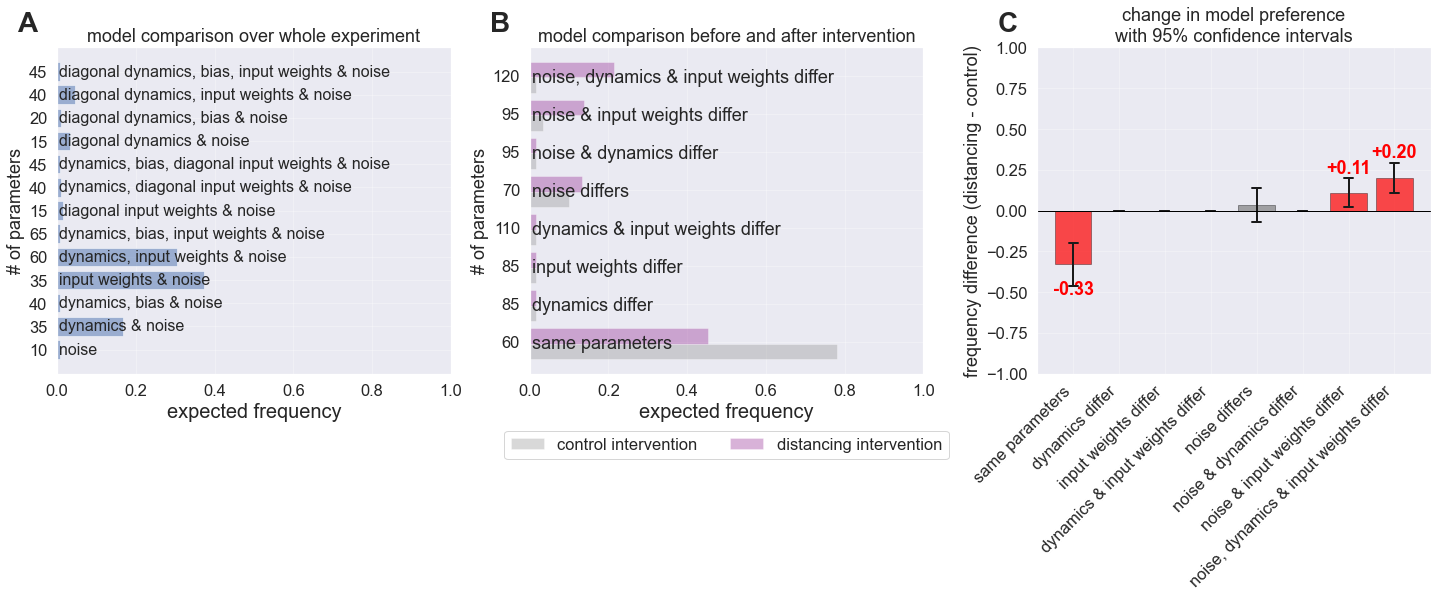

In [30]:
# Function to plot BIC scores for model comparison
def expected_freq_plot(fig, axs, plot_number):

    fitting_labels = [['diagonal dynamics, bias, input weights & noise', \
                  'diagonal dynamics, input weights & noise', \
                  'diagonal dynamics, bias & noise', \
                  'diagonal dynamics & noise', \
                  'dynamics, bias, diagonal input weights & noise', \
                  'dynamics, diagonal input weights & noise', \
                  'diagonal input weights & noise', \
                  'dynamics, bias, input weights & noise', \
                  'dynamics, input weights & noise', \
                  'input weights & noise', \
                  'dynamics, bias & noise', \
                  'dynamics & noise', \
                  'noise'],
                     ['noise, dynamics & input weights differ', \
                      'noise & input weights differ', \
                      'noise & dynamics differ', \
                      'noise differs', \
                      'dynamics & input weights differ', \
                      'input weights differ', \
                      'dynamics differ', \
                      'same parameters']]

    condition_label = ['control intervention', 'distancing intervention']

    # subplot 1 BIC over whole time series
    # calculate AIC and BIC 
    Ndatapoints = np.prod(np.shape(mood_ratings)[:2])
    num_params = np.array([10, 35, 40, 35, 60, 65, 15, 40, 45, 15, 20, 40, 45])
    aic = np.empty([Nsj, len(num_params)])
    bic = np.empty([Nsj, len(num_params)])
    log_evidence = np.empty([Nsj, len(num_params)])
    for sj in range(Nsj):
        num_datapoints = np.prod(np.shape(data[sj]['ratings']))
        for p in range(len(num_params)):
            aic[sj, p], bic[sj, p] = emo.AICBIC_calc(data[sj]['ll'][p], num_datapoints, num_params[p])
            log_evidence[sj,p] = -0.5 * bic[sj, p]
    pxp, expected_freq, alpha = random_effects_bms(log_evidence)

    b = axs[0].barh(np.arange(len(expected_freq)), expected_freq, align='center', alpha=0.5)
    axs[0].set_yticks(range(len(data[0]['ll'])))
    axs[0].set_yticks(range(len(fitting_labels[0])))
    axs[0].set_yticklabels(num_params)
    axs[0].set_ylabel('# of parameters')
    for bar, label in zip(axs[0].patches, fitting_labels[0][::-1]):
        axs[0].text(0.005, bar.get_y()+bar.get_height()/2, label, ha = 'left', va = 'center', size=16) 
    axs[0].set_xlabel('expected frequency', fontsize=20);
    axs[0].set_title('model comparison over whole experiment');
    axs[0].text(-0.1, 1.05, plot_number[0], transform=axs[0].transAxes, weight='bold', size=28)
    axs[0].set_xlim([0,1]);
    axs[0].grid(True, alpha=0.3)

    # subplot 2 split fitting in before and after intervention
    # loglikelihood
    num_params = np.array([60, 85, 85, 110, 70, 95, 95, 120])
    aic_split = np.empty([Nsj, len(num_params)])
    bic_split = np.empty([Nsj, len(num_params)])
    log_evidence_split = np.empty([Nsj, len(num_params)])
    for sj in range(Nsj):
        num_datapoints = np.prod(np.shape(data[sj]['ratings']))
        for p in range(len(num_params)):
            aic_split[sj, p], bic_split[sj, p] = emo.AICBIC_calc(data[sj]['ll_split'][p], num_datapoints, num_params[p])
            log_evidence_split[sj,p] = -0.5 * bic_split[sj, p]    
    
    width = 0.4
    for i in range(2):
        pxp, expected_freq, alpha = random_effects_bms(log_evidence_split[df['randomized_condition']==i,:])
        b = axs[1].barh(np.arange(len(expected_freq)) + i*width, expected_freq, width, \
                align='center', alpha=0.3, label=condition_label[i], color=palette[3-(i*2)])
        
    axs[1].set_title('model comparison before and after intervention')
    axs[1].set_yticks(np.arange(len(fitting_labels[1]))+0.25)
    axs[1].set_yticklabels(num_params)
    axs[1].set_ylabel('# of parameters')
    axs[1].set_xlabel('expected frequency', fontsize=20);
    for bar, label in zip(axs[1].patches, fitting_labels[1][::-1]):
        axs[1].text(0.005, bar.get_y()+bar.get_height()/2 + width/2, label, ha = 'left', va = 'center', size=18)
    axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True);
    axs[1].text(-0.1, 1.05, plot_number[1], transform=axs[1].transAxes, weight='bold', size=28)
    axs[1].set_xlim([0,1]);
    axs[1].grid(True, alpha=0.3)
    
    # Plot 3: Difference in frequencies with confidence intervals
    freq_control, freq_treatment, ci_lower, ci_upper = test_group_model_differences(
        log_evidence_split[df['randomized_condition']==0,:], 
        log_evidence_split[df['randomized_condition']==1,:])
    
    x = np.arange(len(fitting_labels[1]))
    freq_diff = freq_treatment - freq_control
    colors = ['red' if (ci_lower[i] > 0 or ci_upper[i] < 0) else 'gray' for i in range(len(fitting_labels[1]))]

    bars3 = axs[2].bar(x, freq_diff, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

    # Add confidence intervals
    for i in range(len(fitting_labels[1])):
        axs[2].plot([i, i], [ci_lower[i], ci_upper[i]], 'k-', linewidth=2)
        axs[2].plot([i-0.1, i+0.1], [ci_lower[i], ci_lower[i]], 'k-', linewidth=2)
        axs[2].plot([i-0.1, i+0.1], [ci_upper[i], ci_upper[i]], 'k-', linewidth=2)

    axs[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
#     axs[2].set_xlabel('model')
    axs[2].set_ylabel('frequency difference (distancing - control)')
    axs[2].set_title('change in model preference\nwith 95% confidence intervals')
    axs[2].set_xticks(x)
    axs[2].set_ylim([-1,1])
    axs[2].set_xticklabels(fitting_labels[1][::-1], rotation=45, ha='right')
    axs[2].grid(True, alpha=0.3)
    axs[2].text(-0.1, 1.05, 'C', transform=axs[2].transAxes, weight='bold', size=28)

    # Add text annotations for significant changes
    significant_models = []
    for i in range(len(fitting_labels[1])):
        if ci_lower[i] > 0 or ci_upper[i] < 0:
            significant_models.append(i)
            if np.abs(freq_diff[i]) > 0.05:
                if freq_diff[i] > 0:
                    axs[2].text(i, freq_diff[i] + 0.1, f'+{freq_diff[i]:.2f}', 
                            ha='center', va='bottom', fontweight='bold', color='red')
                else:
                    axs[2].text(i, freq_diff[i] - 0.1, f'{freq_diff[i]:.2f}', 
                            ha='center', va='top', fontweight='bold', color='red')

     
fig, axs = plt.subplots(1, 3, figsize=(24, 6))
sns.set(style='white', font_scale=1.5)
expected_freq_plot(fig, axs, ['A', 'B'])
pos2 = axs[2].get_position()
axs[2].set_position([pos2.x0 + 0.02, pos2.y0, pos2.width, pos2.height])
if debug == False:
    plt.savefig(filepath + 'results/figures/random_effects_plot.png', bbox_inches='tight')

---
Fit Quality
---
assessed by comparing, for each subject and emotion, the posterior mean trajectory (averaged over multiple samples from the fitted Kalman filter) against observed emotion ratings, quantifying both explained variance (R²) and peak temporal correlation (cross-correlation at optimal lag), with MSE decomposed into bias and amplitude components to characterise the source of any misfit.

In [31]:
import numpy as np
from scipy.signal import correlate, coherence

def peak_cross_correlation(obs, pred):
    o = obs - np.mean(obs)
    p = pred - np.mean(pred)
    cc = correlate(o, p, mode='full')
    cc_norm = cc / (np.std(o) * np.std(p) * len(o))
    return np.max(cc_norm)

def decompose_r2(obs, pred):
    r = np.corrcoef(obs, pred)[0, 1]
    bias = np.mean(pred) - np.mean(obs)
    std_ratio = np.std(pred) / np.std(obs)
    mse = np.mean((obs - pred)**2)
    mse_bias = bias**2
    mse_phase_amp = np.var(obs) * (1 + std_ratio**2 - 2 * r * std_ratio)
    return {
        'r': r,
        'bias': bias,
        'std_ratio': std_ratio,
        'mse_bias_frac': mse_bias / mse if mse > 1e-10 else np.nan,
        'mse_phase_amp_frac': mse_phase_amp / mse if mse > 1e-10 else np.nan,
    }

def compute_r2_per_subject_emotion(data, inp, emotion_names=None, n_samples=1):
    n_subjects = len(data)
    n_emotions = 5
    T = np.shape(data[0]['ratings'])[1]
    r2 = np.full((n_subjects, n_emotions), np.nan)
    cc = np.full((n_subjects, n_emotions), np.nan)
    sampled = []

    for i, sj in enumerate(range(n_subjects)):
        x_sum = np.zeros((T, n_emotions))

        for _ in range(n_samples):
            x = np.empty((T, n_emotions))
            for t in range(2):
                inp_split = inp[t*int(T/2):t*int(T/2) + int(T/2), :]
                _, x[t*int(T/2):t*int(T/2) + int(T/2), :] = \
                    data[sj]['results_split'][13+t].sample(
                        int(T/2),
                        initial_state=data[sj]['ratings'][:, t*int(T/2)],
                        control_inputs=inp_split
                    )
            x_sum += x

        x_mean = x_sum / n_samples
        sampled.append(x_mean)
        obs = data[sj]['ratings'].T  # (T, n_emotions)

#         print(f"\n--- Subject {sj} ---")
        for e in range(n_emotions):
            ename = emotion_names[e] if emotion_names else f'emotion_{e}'
            obs_e = obs[:, e]
            pred_e = x_mean[:, e]
            mask = ~np.isnan(obs_e)
            obs_valid = obs_e[mask]
            pred_valid = pred_e[mask]

            if len(obs_valid) < 2:
                print(f"  {ename:<12} | skipped (insufficient data)")
                continue

            ss_res = np.sum((obs_valid - pred_valid) ** 2)
            ss_tot = np.sum((obs_valid - np.mean(obs_valid)) ** 2)
            r2[i, e] = np.nan if ss_tot < 1e-10 else 1 - ss_res / ss_tot

            cc[i, e] = peak_cross_correlation(obs_valid, pred_valid)
            
            d = decompose_r2(obs_valid, pred_valid)

    if emotion_names:
        r2_df = pd.DataFrame(r2, columns=emotion_names)
        cc_df = pd.DataFrame(cc, columns=emotion_names)
    else:
        r2_df = pd.DataFrame(r2)
        cc_df = pd.DataFrame(cc)

    return r2_df, cc_df, sampled

In [41]:
data = np.load(filepath + 'results/fit_experiment_included.npy', allow_pickle=True)
r2_df, cc_df, sampled = compute_r2_per_subject_emotion(data, inp, mood_categories, n_samples=100)

print("\nMean R² per emotion:");      print(r2_df.mean().round(3))
print(np.round(r2_df.mean().mean(),3))
print("\nMean peak CC per emotion:");  print(cc_df.mean().round(3))
print(np.round(cc_df.mean().mean(),3))
print("\nNaN counts per emotion:");    print(r2_df.isna().sum())


Mean R² per emotion:
disgusted    0.636
amused       0.575
calm         0.568
anxious      0.558
sad          0.640
dtype: float64
0.596

Mean peak CC per emotion:
disgusted    0.793
amused       0.753
calm         0.764
anxious      0.739
sad          0.795
dtype: float64
0.769

NaN counts per emotion:
disgusted    0
amused       0
calm         0
anxious      0
sad          0
dtype: int64


---
Specific example subjects in Figure 4 C)
---

In [53]:
data = np.load(filepath + 'results/fit_experiment_included.npy', allow_pickle=True)

example_subjects = [16,58] # random examples are nr 16 and 61 but bc 3 subjects were excluded 61 -> 58

fitting_labels = ['noise, dynamics & input weights differ', \
                      'noise & input weights differ', \
                      'noise & dynamics differ', \
                      'noise differs', \
                      'dynamics & input weights differ', \
                      'input weights differ', \
                      'dynamics differ', \
                      'same parameters']

example_subject_label = ['subject upper panel Figure 4 C) distancing group', \
                'subject lower panel Figure 4 C) control group']

for j,s in enumerate(example_subjects):
    print(example_subject_label[j] + ' (nr ' + str(s) + ')')
    print("\nMean R² and peak CC per emotion:\n")
    print(pd.concat([r2_df.iloc[s], cc_df.iloc[s]],axis=1))
    n_obs = np.array([data[s]['ratings'].shape[1] for i in range(len(data[s]['ll_split']))])
    n_parameter = np.array([60, 85, 85, 110, 70, 95, 95, 120])
    aic, bic = emo.AICBIC_calc(data[s]['ll_split'], n_obs, n_parameter)
    subject_bic_df = pd.DataFrame({'model incl params': fitting_labels[::-1], 'number of parameters': n_parameter, 'bic': bic})
    display(subject_bic_df)
    


subject upper panel Figure 4 C) distancing group (nr 16)

Mean R² and peak CC per emotion:

                 16        16
disgusted  0.732791  0.857374
amused     0.596012  0.776895
calm       0.700726  0.838708
anxious    0.625559  0.791485
sad        0.582877  0.763597


,model incl params,number of parameters,bic
0,same parameters,60,4821.132612
1,dynamics differ,85,4859.635808
2,input weights differ,85,4852.246340
3,dynamics & input weights differ,110,4888.023567
4,noise differs,70,4809.487638
5,noise & dynamics differ,95,4847.341449
6,noise & input weights differ,95,4823.958161
7,"noise, dynamics & input weights differ",120,4806.785602


subject lower panel Figure 4 C) control group (nr 58)

Mean R² and peak CC per emotion:

                 58        58
disgusted  0.743753  0.863501
amused     0.828189  0.911359
calm       0.812714  0.903435
anxious    0.815338  0.902980
sad        0.834400  0.914207


,model incl params,number of parameters,bic
0,same parameters,60,4011.570635
1,dynamics differ,85,4058.408370
2,input weights differ,85,4083.629397
3,dynamics & input weights differ,110,4017.171793
4,noise differs,70,3979.070321
5,noise & dynamics differ,95,3915.024373
6,noise & input weights differ,95,3952.523543
7,"noise, dynamics & input weights differ",120,3723.247180
